# CORRELATIONS IN VLP

This file will be used to rough perform the VLP correlations and build functions for them. Given question is tubing OD of 2 7/8" nad ID of 2.441". Casing ID is 5 1/2". GOR is 1000, Ql = 20 m3/day. Pe = 120 kg/cm2 and Pwf = 100 kg/cm2

## INDEX

1. [PVT](#1)
2. [Hagedron-Brown](#2)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

<a name = "1"></a>
## PVT

In [ ]:
class BlackOilPVT:
    """
    A comprehensive Black Oil PVT calculator using standard industry empirical correlations
    (Standing, Beggs-Robinson, Lee-Gonzalez-Eakin, Dranchuk-Abou-Kassem).
    Assumes standard US Oilfield Units.
    """

    def __init__(self, sg_gas = 0.65, sg_oil = 0.84, oil_api = None, sg_water=1.03, watercut = 0.0):
        """
        Initializes the fluid with its constant surface properties.

        Args:
            sg_gas (float): Specific gravity of gas (Air = 1.0).
            sg_oil (float): Specific gravity of oil (Water = 1.0).
            sg_water (float, optional): Specific gravity of water. Defaults to 1.03.
        """
        self.sg_g = sg_gas

        self.sg_o = 141.5/(131.5+oil_api) if oil_api else sg_oil
        self.wor = watercut / (1.0 - watercut)
        self.wc = watercut
        self.sg_w = sg_water

        # Calculate API gravity (used in almost all oil correlations)
        self.api = (141.5 / self.sg_o) - 131.5

    def get_pseudo_critical(self):
        """
        Calculates Sutton's pseudo-critical temperature and pressure for natural gas.

        Returns:
            tuple:
                Tpc (float): Pseudo-critical temperature in Rankine (°R).
                Ppc (float): Pseudo-critical pressure in psia.
        """
        Tpc = 187 + 330 * self.sg_g - 71.5 * self.sg_g**2
        Ppc = 667 + 15 * self.sg_g - 37.5 * self.sg_g**2
        return Tpc, Ppc

    def calculate_dak_z_factor(self, P, T, gamma_g, max_iter=100, tolerance=1e-6):
        """
        Calculates the Gas Z-factor using the Dranchuk-Abou-Kassem (DAK)
        equation of state for dry natural gas via Newton-Raphson iteration.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            gamma_g (float): Gas specific gravity.
            max_iter (int, optional): Maximum iterations for the solver. Defaults to 100.
            tolerance (float, optional): Convergence tolerance. Defaults to 1e-6.

        Returns:
            float: Gas compressibility factor (Z-factor), dimensionless.
        """
        T_r = T + 459.67
        Tpc, Ppc = self.get_pseudo_critical()
        Tpr = T_r / Tpc
        Ppr = P / Ppc

        A1, A2, A3 = 0.3265, -1.0700, -0.5339
        A4, A5, A6 = 0.01569, -0.05165, 0.5475
        A7, A8, A9 = -0.7361, 0.1844, 0.1056
        A10, A11 = 0.6134, 0.7210

        c1 = A1 + A2/Tpr + A3/(Tpr**3) + A4/(Tpr**4) + A5/(Tpr**5)
        c2 = A6 + A7/Tpr + A8/(Tpr**2)
        c3 = A9 * (A7/Tpr + A8/(Tpr**2))
        c4 = A10 / (Tpr**3)

        rho_r = 0.27 * Ppr / Tpr

        for i in range(max_iter):
            term_exp = np.exp(-A11 * (rho_r**2))

            f = (1.0 + c1*rho_r + c2*(rho_r**2) - c3*(rho_r**5) +
                 c4*(rho_r**2)*(1.0 + A11*(rho_r**2))*term_exp - (0.27 * Ppr / (rho_r * Tpr)))

            df = (c1 + 2.0*c2*rho_r - 5.0*c3*(rho_r**4) +
                  2.0*c4*rho_r*(1.0 + A11*(rho_r**2) - A11*(rho_r**3) + A11**2 * (rho_r**4))*term_exp +
                  (0.27 * Ppr / ((rho_r**2) * Tpr)))

            rho_r_new = rho_r - f / df

            if abs(rho_r_new - rho_r) < tolerance:
                z_factor = 0.27 * Ppr / (rho_r_new * Tpr)
                return round(z_factor, 4)

            rho_r = rho_r_new

        raise ValueError("Z-factor solver did not converge. Check input parameters.")

    def calc_bubble_point(self, T, Rsb):
        """
        Calculates Bubble Point Pressure (Pb) using Standing's Correlation.

        Args:
            T (float): Local temperature in Fahrenheit (°F).
            Rsb (float): Solution GOR at bubble point (Initial Producing GOR) in scf/STB.

        Returns:
            float: Bubble point pressure in psia.
        """
        a = 0.00091 * T - 0.0125 * self.api
        pb = 18.2 * (((Rsb / self.sg_g) ** 0.83) * (10 ** a) - 1.4)
        return max(pb, 14.7)

    def calc_rs(self, P, T, Pb, Rsb):
        """
        Calculates Solution Gas-Oil Ratio (Rs) using Standing's Correlation.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Pb (float): Bubble point pressure in psia.
            Rsb (float): Solution GOR at bubble point in scf/STB.

        Returns:
            float: Solution Gas-Oil Ratio in scf/STB.
        """
        if P >= Pb:
            return Rsb
        a = 0.00091 * T - 0.0125 * self.api
        rs = self.sg_g * (((P / 18.2) + 1.4) * (10 ** -a)) ** 1.2048
        return max(rs, 0.0)

    def calc_bo(self, P, T, Rs, Pb):
        """
        Calculates Oil Formation Volume Factor (Bo) using Standing's Correlation.
        Includes simplified Vasquez-Beggs isothermal compressibility for undersaturated conditions.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Rs (float): Solution Gas-Oil Ratio at local pressure in scf/STB.
            Pb (float): Bubble point pressure in psia.

        Returns:
            float: Oil Formation Volume Factor (Bo) in bbl/STB.
        """
        F = Rs * np.sqrt(self.sg_g / self.sg_o) + 1.25 * T
        bo_sat = 0.9759 + 0.00012 * (F ** 1.175)

        if P <= Pb:
            return bo_sat

        co = (5 * Rs + 17.2 * T - 1180 * self.sg_g + 12.61 * self.api - 1433) / (P * 10**5)
        co = max(co, 5e-6)
        bo_under = bo_sat * np.exp(-co * (P - Pb))
        return bo_under

    def calc_bg(self, P, T, Z):
        """
        Calculates Gas Formation Volume Factor (Bg) using the Real Gas Law.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Z (float): Gas compressibility factor.

        Returns:
            float: Gas Formation Volume Factor (Bg) in ft³/scf.
        """
        T_rankine = T + 460.0
        bg = 0.02827 * Z * T_rankine / P
        return bg

    def calc_bw(self, P, T):
        """
        Calculates Water Formation Volume Factor (Bw) using polynomial approximation.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).

        Returns:
            float: Water Formation Volume Factor (Bw) in bbl/STB.
        """
        delta_T = T - 60.0
        bw = 1.0 + 1.2e-4 * delta_T + 1e-6 * (delta_T ** 2) - 3.33e-6 * P
        return max(bw, 1.0)

    def calc_density_oil(self, Rs, Bo):
        """
        Calculates in-situ Oil Density.

        Args:
            Rs (float): Solution Gas-Oil Ratio at local pressure in scf/STB.
            Bo (float): Oil Formation Volume Factor at local pressure in bbl/STB.

        Returns:
            float: In-situ oil density in lbm/ft³.
        """
        rho_o_insitu = (350.0 * self.sg_o + 0.0764 * self.sg_g * Rs) / (5.615 * Bo)
        return rho_o_insitu

    def calc_density_gas(self, P, T, Z):
        """
        Calculates in-situ Gas Density using the Real Gas Law.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Z (float): Gas compressibility factor.

        Returns:
            float: In-situ gas density in lbm/ft³.
        """
        T_rankine = T + 460.0
        rho_g_insitu = 28.967 * self.sg_g * P / (Z * 10.732 * T_rankine)
        return rho_g_insitu

    def calc_viscosity_oil(self, P, T, Rs, Pb):
        """
        Calculates Oil Viscosity using Beggs-Robinson Correlation.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Rs (float): Solution Gas-Oil Ratio at local pressure in scf/STB.
            Pb (float): Bubble point pressure in psia.

        Returns:
            float: Oil viscosity in centipoise (cp).
        """
        z = 3.0324 - 0.02023 * self.api
        y = 10 ** z
        x = y * (T ** -1.163)
        mu_od = 10 ** x - 1.0

        a = 10.715 * ((Rs + 100) ** -0.515)
        b = 5.44 * ((Rs + 150) ** -0.338)
        mu_os = a * (mu_od ** b)

        if P <= Pb:
            return mu_os

        m = 2.6 * (P ** 1.187) * np.exp(-11.513 - 8.98e-5 * P)
        mu_o_under = mu_os * ((P / Pb) ** m)
        return mu_o_under

    def calc_viscosity_gas(self, P, T, Z):
        """
        Calculates Gas Viscosity using the Lee-Gonzalez-Eakin correlation.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Z (float): Gas compressibility factor.

        Returns:
            float: Gas viscosity in centipoise (cp).
        """
        T_rankine = T + 460.0
        Mg = 28.97 * self.sg_g
        rho_g = self.calc_density_gas(P, T, Z) / 62.4

        K = (9.379 + 0.01607 * Mg) * (T_rankine ** 1.5) / (209.2 + 19.26 * Mg + T_rankine)
        X = 3.448 + (986.4 / T_rankine) + 0.01009 * Mg
        Y = 2.447 - 0.2224 * X

        mu_g = 1e-4 * K * np.exp(X * (rho_g ** Y))
        return mu_g

    def calc_viscosity_water(self, T):
        """
        Calculates water viscosity using the Brill & Beggs correlation.

        Args:
            T (float): Local temperature in Fahrenheit (°F).

        Returns:
            float: Water viscosity in centipoise (cp).
        """
        return np.exp(1.003 - 0.01479 * T + 0.00001982 * T**2)

    def calc_surface_tension_oil(self, P, T):
        """
        Calculates Liquid-Gas Surface Tension for oil using Baker-Swerdloff.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).

        Returns:
            float: Oil surface tension in dynes/cm.
        """
        sigma_68 = 39.0 - 0.2571 * self.api
        sigma_100 = 37.5 - 0.2571 * self.api

        if T > 100:
            sigma_dead = sigma_100 - (T - 100) * 0.05
        else:
            sigma_dead = sigma_68 - (T - 68) * ((sigma_68 - sigma_100) / 32.0)

        sigma_dead = max(sigma_dead, 1.0)
        sigma_live = sigma_dead * np.exp(-0.0002 * P)
        return max(sigma_live, 1.0)

    def calc_surface_tension_water(self, T):
        """
        Calculates Water-Gas Surface Tension.

        Args:
            T (float): Local temperature in Fahrenheit (°F).

        Returns:
            float: Water surface tension in dynes/cm.
        """
        sigma_w = 75.0 - 0.116 * T
        return max(sigma_w, 40.0)

    def calc_M(self, gor):
      """
      Caclulates M.

      Args:
        glr (float): Gas-Oil Ratio.

      Returns:
        M (float): no units
      """
      glr  = gor/(1+self.wc)
      return self.sg_o*350.52/(1+self.wor) + self.sg_w * 350.52 * self.wor/(1+self.wor) + self.sg_g * 0.0764 * glr

    def fluid_properties_dict(self, P, T, Rsb, Pb = 0):
        """
        Calculates all fluid properties at a specific pressure and temperature node.
        Correctly blends oil and water properties based on in-situ volume fractions.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Rsb (float): Initial producing Gas-Oil Ratio in scf/STB.
            Pb (float): Bubble-point pressure in psia.

        Returns:
            dict: A dictionary containing all blended liquid and gas properties required
                  by multiphase flow correlations like Hagedorn-Brown.
        """

        Pb = self.calc_bubble_point(T, Rsb) if Pb == 0 else Pb

        Rs = self.calc_rs(P, T, Pb, Rsb)
        Z = self.calculate_dak_z_factor(P, T, self.sg_g)
        M = self.calc_M(Rs)

        Bo = self.calc_bo(P, T, Rs, Pb)
        Bw = self.calc_bw(P, T)
        Bg = self.calc_bg(P, T, Z)

        # Calculate In-Situ Volume Fractions for Liquid Blending
        total_liquid_vol = Bo + (self.wor * Bw)
        fo = 1/(1+self.wor)
        fw = (self.wor) / (1+self.wor)

        # Pure Phase Properties
        rho_o = self.calc_density_oil(Rs, Bo)
        rho_w = 62.4 * self.sg_w
        mu_o = self.calc_viscosity_oil(P, T, Rs, Pb)
        mu_w = self.calc_viscosity_water(T)
        sigma_o = self.calc_surface_tension_oil(P, T)
        sigma_w = self.calc_surface_tension_water(T)

        # In-Situ Blended Liquid Properties
        rho_l = (62.4*self.sg_o + (Rs*self.sg_g*0.0764/5.615))*(1/(1+self.wor))/Bo + 62.4*self.sg_w*self.wor/(1+self.wor)
        mu_l = (mu_o * fo) + (mu_w * fw)
        sigma_l = (sigma_o * fo) + (sigma_w * fw)

        return {
            "M": M,
            "Pb": Pb,
            "Rsb": Rsb,
            "gor": Rs,
            "glr": Rs/(1+self.wc),
            "rho_l": rho_l,
            "rho_g": self.calc_density_gas(P, T, Z),
            "mu_l": mu_l,
            "mu_g": self.calc_viscosity_gas(P, T, Z),
            "sigma_l": sigma_l,
            "Bo": Bo,
            "Bg": Bg,
            "Bw": Bw,
            "Pr": P,
            "Tr": T,
            "Z": Z
        }

<a name = "2"></a>
## HAGEDRON-BROWN


In [ ]:
class HagedornBrown:
    """
    Calculates multiphase flow pressure gradients and VLP curves for vertical wellbores
    using the Hagedorn-Brown correlation and a coupled Black Oil PVT model.
    """

    def __init__(self, tubing_id, tubing_od, casing_id, roughness, pvt_model, fluid_properties, watercut=0.0, theta=0.0):
        """
        Initializes the wellbore geometry and fluid composition parameters.

        Args:
            tubing_id (float): Tubing inner diameter in feet (ft).
            tubing_od (float): Tubing outer diameter in feet (ft).
            casing_id (float): Casing inner diameter in feet (ft).
            roughness (float): Absolute pipe roughness in feet (ft).
            pvt_model (object): Instance of the BlackOilPVT class.
            gor (float): Total Gas-Oil Ratio in scf/STB.
            watercut (float): Watercut as a decimal fraction (0.0 to 1.0).
            theta (float): Well deviation from vertical in degrees (0 = vertical).
        """
        self.tid = tubing_id
        self.tod = tubing_od
        self.cid = casing_id
        self.roughness = roughness
        self.pvt_model = pvt_model
        self.wc = watercut
        self.wor = watercut / (1.0 - watercut)
        self.theta = np.radians(theta)
        self.Ap = (np.pi / 4.0) * self.tid**2
        self.Pb = pvt_model.calc_bubble_point
        self.fp = fluid_properties

    def update_fluid_properties(self, P, T, Ql):
        """
        Calculates fluid properties at local conditions and updates in-situ velocities.

        Args:
            P (float): Local pressure in psia.
            T (float): Local temperature in Fahrenheit (°F).
            Ql (float): Surface liquid flow rate in STB/day.
        """
        self.Ql = Ql
        self.fp = self.pvt_model.fluid_properties_dict(P, T, self.fp["Rsb"], self.fp["Pb"])



    def dimensionless_numbers(self):
        """
        Calculates the required Hagedorn-Brown dimensionless groups.

        Returns:
            tuple: Contains Nl, CNl, Nlv, Ngv, Nd (all dimensionless).
        """


        fo = 1.0/(1.0 + self.wor)
        fw = self.wor/(1+self.wor)
        q_liquid_insitu = 5.615 * self.Ql * (self.fp["Bo"] * fo + self.fp["Bw"] * fw)
        self.fp["Vsl"] = q_liquid_insitu / (86400.0 * self.Ap)

        free_gas_scf = max(0.0, self.Ql * (self.fp["glr"] - self.fp["gor"] * fo))
        q_gas_insitu = free_gas_scf * (14.7/self.fp["Pr"]) * ((self.fp["Tr"]+460)/520)*self.fp["Z"]
        self.fp["Vsg"] = q_gas_insitu / (86400.0 * self.Ap)

        self.fp["Vm"] = self.fp["Vsl"] + self.fp["Vsg"]
        base_term = 1.0 / (self.fp["rho_l"] * self.fp["sigma_l"]**3)
        Nl = 0.15726 * self.fp["mu_l"] * (base_term ** 0.25)
        CNl = 0.061 * Nl**3 - 0.0929 * Nl**2 + 0.0505 * Nl + 0.0019

        Nlv = 1.938 * self.fp["Vsl"] * (self.fp["rho_l"] / self.fp["sigma_l"])**0.25
        Ngv = 1.938 * self.fp["Vsg"] * (self.fp["rho_l"] / self.fp["sigma_l"])**0.25
        Nd = 120.872 * self.tid * (self.fp["rho_l"] / self.fp["sigma_l"])**0.5

        return Nl, CNl, Nlv, Ngv, Nd

    def liquid_holdup(self):
        """
        Calculates the physical liquid fraction (holdup) inside the pipe segment.

        Returns:
            float: Liquid holdup fraction (dimensionless, bounded 0.0 to 1.0).
        """
        Nl, CNl, Nlv, Ngv, Nd = self.dimensionless_numbers()
        Ngv_safe = max(Ngv, 1e-6)

        H = (Nlv / (Ngv_safe**0.575)) * (self.fp["Pr"] / 14.7)**0.1 * (CNl / Nd)
        Hl_psi = np.sqrt((0.0047 + 1123.32*H + 729489.64*H**2) / (1 + 1097.1566*H + 722153.97*H**2))
        B = Ngv * (Nlv**0.38) / (Nd**2.14)

        if B <= 0.025:
            psi = 27170*B**3 - 317.52*B**2 + 0.5472*B + 0.9999
        elif B <= 0.055:
            psi = -533.33*B**2 + 58.524*B + 0.1171
        else:
            psi = 2.5714*B + 1.5962

        Hl = max(0.0, min(Hl_psi * psi, 1.0))

        self.fp["rho_m"] = self.fp["rho_l"] * Hl + self.fp["rho_g"] * (1.0 - Hl)
        self.fp["mu_m"] = (self.fp["mu_l"]**Hl) * (self.fp["mu_g"]**(1.0 - Hl))

        return Hl

    def frictional_factor(self):
        """
        Calculates the two-phase Darcy friction factor using the Jain approximation.

        Returns:
            float: Darcy friction factor (dimensionless).
        """
        Hl = self.liquid_holdup()
        lambda_l = self.fp["Vsl"] / max(self.fp["Vm"], 1e-6)
        self.fp["rho_ns"] = self.fp["rho_l"] * lambda_l + self.fp["rho_g"] * (1.0 - lambda_l)
        Re = 2.2*10**-2 * self.Ql * self.fp["M"]/ (self.tid * self.fp["mu_l"]**Hl * self.fp["mu_g"]**(1-Hl))

        if Re < 2000:
            return 64.0 / max(Re, 1.0)
        else:
            return (1.14 - 2.0 * np.log10(self.roughness + 21.25 / (Re ** 0.9))) ** -2

    def calculate_gradient(self):
        """
        Calculates the total multiphase pressure gradient.

        Returns:
            float: Total pressure gradient in psi/ft.
        """
        self.liquid_holdup()
        f = self.frictional_factor()

        dp_dh_el = self.fp["rho_m"] * np.cos(self.theta) / 144.0
        gc = 32.174
        dp_dh_fric = (f * self.fp["rho_ns"] * (self.fp["Vm"]**2)) / (2.0 * gc * self.tid * 144.0)

        return dp_dh_el + dp_dh_fric

    def calculate_pressure_traverse(self, Pth, surface_temp, bottomhole_temp, total_depth, step_size, Ql):
        """
        Calculates the pressure profile down the wellbore using Euler numerical integration.

        Args:
            Pth (float): Wellhead tubing pressure in psia.
            surface_temp (float): Surface temperature in Fahrenheit (°F).
            bottomhole_temp (float): Bottomhole temperature in Fahrenheit (°F).
            total_depth (float): Total vertical depth of the well in feet (ft).
            step_size (float): Depth integration step size in feet (ft).
            Ql (float): Surface liquid flow rate in STB/day.

        Returns:
            tuple:
                depths (list): Array of depth nodes in feet (ft).
                pressures (list): Array of pressures corresponding to depth nodes in psia.
        """
        depths = [0.0]
        pressures = [Pth]
        current_P = Pth
        current_depth = 0.0
        temp_gradient = (bottomhole_temp - surface_temp) / total_depth

        while current_depth < total_depth:
            next_depth = min(current_depth + step_size, total_depth)
            actual_step = next_depth - current_depth
            current_temp = surface_temp + (temp_gradient * current_depth)

            self.update_fluid_properties(current_P, current_temp, Ql)
            dp_dz = self.calculate_gradient()

            current_P += dp_dz * actual_step
            current_depth = next_depth

            depths.append(current_depth)
            pressures.append(current_P)

        return depths, pressures

    def plot_pressure_traverse(self, Pth, surface_temp, bottomhole_temp, total_depth, step_size, Ql):
        """
        Generates a plot of Pressure vs. Depth for a single specified flow rate.

        Args:
            Pth (float): Wellhead tubing pressure in psia.
            surface_temp (float): Surface temperature in Fahrenheit (°F).
            bottomhole_temp (float): Bottomhole temperature in Fahrenheit (°F).
            total_depth (float): Total vertical depth of the well in feet (ft).
            step_size (float): Depth integration step size in feet (ft).
            Ql (float): Surface liquid flow rate in STB/day.

        Returns:
            float: Final bottom-hole flowing pressure (Pwf) in psia.
        """
        depths, pressures = self.calculate_pressure_traverse(Pth, surface_temp, bottomhole_temp, total_depth, step_size, Ql)

        plt.plot(pressures, depths, color='blue', linewidth=2)
        plt.gca().invert_yaxis()
        plt.xlabel('Pressure (psia)')
        plt.ylabel('Depth (ft)')
        plt.title('Pressure Traverse Curve')
        plt.grid(True)
        plt.show()

        return pressures[-1]

    def plot_vlp_curve(self, Pth, surface_temp, bottomhole_temp, depth, Qmin, Qmax, step_size):
        """
        Generates a Vertical Lift Performance (VLP) curve by evaluating bottom-hole
        pressure across a dynamic range of surface liquid flow rates.

        Args:
            Pth (float): Wellhead tubing pressure in psia.
            surface_temp (float): Surface temperature in Fahrenheit (°F).
            bottomhole_temp (float): Bottomhole temperature in Fahrenheit (°F).
            depth (float): Total vertical depth of the well in feet (ft).
            Qmin (int): Minimum surface liquid flow rate to evaluate in STB/day.
            Qmax (int): Maximum surface liquid flow rate to evaluate in STB/day.
            step_size (float): Depth integration step size in feet (ft).
        """
        Pwf_points = []
        rates = np.linspace(Qmin, Qmax, Qmax - Qmin)

        for q in rates:
            depths, pressures = self.calculate_pressure_traverse(Pth, surface_temp, bottomhole_temp, depth, step_size, q)
            Pwf_points.append(pressures[-1])

        plt.plot(rates, Pwf_points, color='blue')
        plt.xlabel('Liquid Rate (stb/day)')
        plt.ylabel('Pwf (psi)')
        plt.title('VLP Curve')
        plt.grid(True)
        plt.show()

    def vlp_curve_plot_linear(self, Pth, depth, Qmin, Qmax, step_size):
      """
      Generates the Vlp curve from Qmin to Qmax with each step of step_size and plots it

      Args:
        Pth (float): Wellhead tubing pressure in psia.
        depth (float): Total vertical depth of the well in feet (ft).
        Qmin (int): Minimum surface liquid flow rate to evaluate in STB/day.
        Qmax (int): Maximum surface liquid flow rate to evaluate in STB/day.
        step_size (float): Depth integration step size in feet (ft).
      """
      Pwf_points = []
      rates = np.linspace(Qmin, Qmax, int((Qmax-Qmin)/step_size))

      for q in rates:
          self.Ql = q
          Pwf = Pth + self.calculate_gradient() * depth
          Pwf_points.append(Pwf)

      plt.plot(rates, Pwf_points, color='blue')
      plt.xlabel('Liquid Rate (stb/day)')
      plt.ylabel('Pwf (psi)')

Calculated Pressure Gradient: 0.0886 psi/ft
Pwf at 5000 ft: 643.02 psi


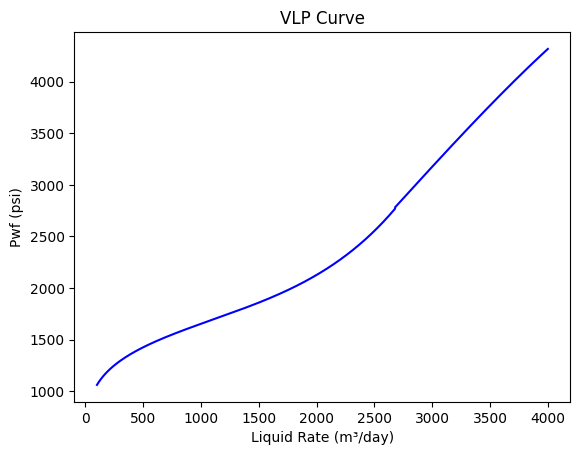

In [ ]:
fluid_props = {
    "rho_l": 62.4, "rho_g": 0.05, "mu_l": 1.0, "mu_g": 0.02,
    "sigma_l": 30.0, "Bo": 1.2, "Bw": 1.0, "Pr": 1706.0, "Tr": 560, "Z": 0.9
}

hb = HagedornBrown(
    tubing_id=2.441/12, tubing_od=2.875/12, casing_id=5.5/12,
    roughness=0.0006, Ql=20, fluid_properties=fluid_props, gor=1000
)

gradient = hb.calculate_gradient()
print(f"Calculated Pressure Gradient: {gradient:.4f} psi/ft")
print(f"Pwf at 5000 ft: {hb.find_Pwf(200, 5000):.2f} psi")
hb.VLP_curve(100, 8000, 100, 4000)


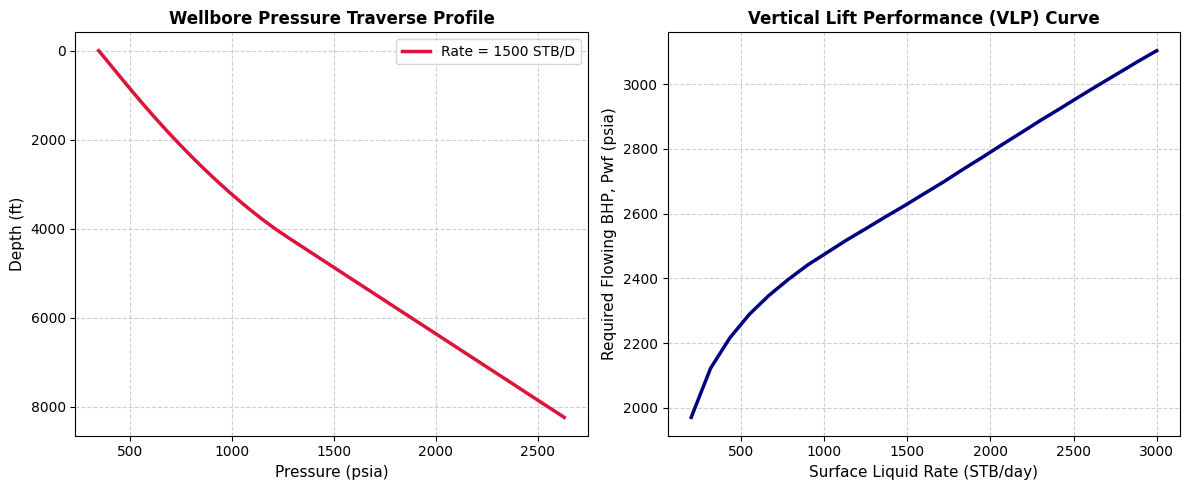

--- Production Hydraulics Diagnostics ---
At a liquid target of 1500.0 STB/day:
  -> Tubing Head Pressure (Pth): 346.6 psia
  -> Required Bottomhole Flowing Pressure (Pwf): 3103.31 psia
  -> Average total pressure gradient: 0.3344 psi/ft


In [ ]:
# --- Realistic PVT Initializations ---
    # Oil gravity = 35 API (~0.85 sg), Gas gravity = 0.65 (sweet gas)
pvt_data = BlackOilPVT(sg_gas=0.915, sg_oil=0.82, sg_water=1.07)


    # --- Realistic Well Geometry & Operational Constraints ---
    # Tubing: 2.875" OD, 2.441" ID -> 2.441/12 = 0.2034 ft Inner Diameter
wellbore = HagedornBrown(
        tubing_id=0.2034,
        tubing_od=0.2396,
        casing_id=0.5042,
        roughness=0.0006,
        pvt_model=pvt_data,
        gor = 480, # 800 scf/bbl gas-liquid ratio
        watercut=0.00,     # 30% watercut
        theta=0.0          # Perfectly vertical well
    )

    # Well Environment Constants
P_tubing_head = 346.6    # Wellhead backpressure (psia)
T_surface = 80.0          # Surface temperature (°F)
T_reservoir = 130.0       # Reservoir/Bottomhole temperature (°F)
total_depth_ft = 8244.0    # 9,000 ft well vertical depth
dz_step = 200.0           # 200 ft integration cells

    # -----------------------------------------------------------------
    # SIMULATION 1: Generate & Plot Pressure Traverse at 1,500 STB/day
    # -----------------------------------------------------------------
target_rate = 1500.0
z_nodes, p_nodes = wellbore.calculate_pressure_traverse(
        P_tubing_head, T_surface, T_reservoir, total_depth_ft, dz_step, target_rate
    )

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(p_nodes, z_nodes, color='crimson', linewidth=2.5, label=f'Rate = {target_rate:.0f} STB/D')
plt.gca().invert_yaxis()
plt.xlabel('Pressure (psia)', fontsize=11)
plt.ylabel('Depth (ft)', fontsize=11)
plt.title('Wellbore Pressure Traverse Profile', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# -----------------------------------------------------------------
# SIMULATION 2: Generate & Plot Vertical Lift Performance (VLP) Curve
# -----------------------------------------------------------------
rates = np.linspace(200, 3000, 25)
pwf_points = []

for q in rates:
        _, p_profile = wellbore.calculate_pressure_traverse(
            P_tubing_head, T_surface, T_reservoir, total_depth_ft, dz_step, q
        )
        pwf_points.append(p_profile[-1])

plt.subplot(1, 2, 2)
plt.plot(rates, pwf_points, color='navy', linewidth=2.5)
plt.xlabel('Surface Liquid Rate (STB/day)', fontsize=11)
plt.ylabel('Required Flowing BHP, Pwf (psia)', fontsize=11)
plt.title('Vertical Lift Performance (VLP) Curve', fontsize=12, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Dynamic diagnostic summary statement
print(f"--- Production Hydraulics Diagnostics ---")
print(f"At a liquid target of {target_rate} STB/day:")
print(f"  -> Tubing Head Pressure (Pth): {P_tubing_head} psia")
print(f"  -> Required Bottomhole Flowing Pressure (Pwf): {p_profile[-1]:.2f} psia")
print(f"  -> Average total pressure gradient: {(p_profile[-1] - P_tubing_head)/total_depth_ft:.4f} psi/ft")

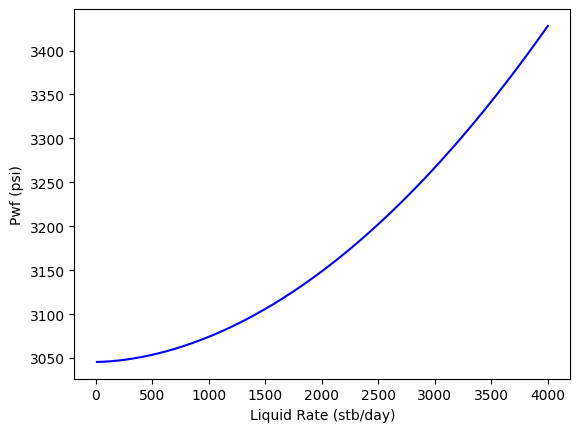

In [ ]:
pvt_data = BlackOilPVT(sg_gas=0.915, sg_oil=141.5/(131.5+41.06), sg_water=1.07, watercut =0.00 )
fp = pvt_data.fluid_properties_dict(2500, 130, 480, 1373)

hg = HagedornBrown(2.441/12, 2.875/12, 5.5/12, 0.0006, pvt_data, fp)
hg.vlp_curve_plot_linear(346.6, 8245, 10, 4000, 5)


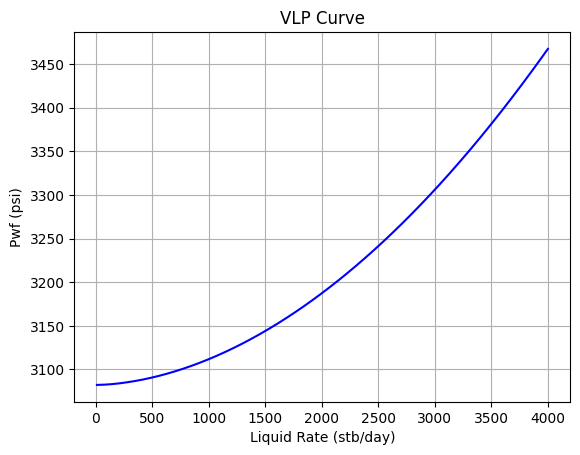

In [ ]:
pvt_data = BlackOilPVT(sg_gas=0.915, sg_oil=141.5/(131.5+41.06), sg_water=1.07, watercut =0.00 )
fp = pvt_data.fluid_properties_dict(2500, 130, 480, 1373)

hg = HagedornBrown(2.441/12, 2.875/12, 5.5/12, 0.0006, pvt_data, fp)
hg.plot_vlp_curve(346.6, 80, 130, 8245, 10, 4000, 5)